## 0. Import Library & Upload Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()  # pilih file logging_monitoring_anomalies.csv

Saving logging_monitoring_anomalies.csv to logging_monitoring_anomalies.csv


In [ ]:
df = pd.read_csv('logging_monitoring_anomalies.csv')
df.head()

,Timestamp,Anomaly_ID,Anomaly_Type,Severity,Status,Source,Alert_Method,Response_Time_ms,Resolution_Time_min,Affected_Services,...,Anomaly_Duration_sec,TimeZone,User_ID,Location,Patch_Level,Service_Type,Transaction_ID,Alert_Count,Retry_Count,Escalation_Level
0,2025-01-01 00:00:00,1,Storage,Low,Open,Database,SMS,2612,25,18,...,43,PST,23536,APAC,4,Cache,195883,40,7,3
1,2025-01-01 00:01:00,2,Database,Medium,Closed,Server,Email,5375,2046,3,...,7146,IST,10030,US,0,API,952949,18,7,0
2,2025-01-01 00:02:00,3,Network,High,Acknowledged,Cloud,Webhook,7789,3016,3,...,1588,PST,11907,EU,12,Web,534080,32,6,1
3,2025-01-01 00:03:00,4,Application,Medium,Open,Database,SMS,361,757,9,...,1301,PST,32768,APAC,7,Web,452955,36,0,3
4,2025-01-01 00:04:00,5,Database,Low,Acknowledged,Firewall,SMS,935,1077,4,...,4336,PST,26202,APAC,14,Web,694799,39,8,2


## 1. Overview & Cek Kualitas Data



In [ ]:
print('Jumlah baris & kolom:', df.shape)
print()
df.info()

Jumlah baris & kolom: (100000, 31)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Timestamp             100000 non-null  object 
 1   Anomaly_ID            100000 non-null  int64  
 2   Anomaly_Type          100000 non-null  object 
 3   Severity              100000 non-null  object 
 4   Status                100000 non-null  object 
 5   Source                100000 non-null  object 
 6   Alert_Method          100000 non-null  object 
 7   Response_Time_ms      100000 non-null  int64  
 8   Resolution_Time_min   100000 non-null  int64  
 9   Affected_Services     100000 non-null  int64  
 10  User_Role             100000 non-null  object 
 11  Host_IP               100000 non-null  object 
 12  Process_ID            100000 non-null  int64  
 13  Error_Code            100000 non-null  int64  
 14  CPU_Usage_Percent

In [ ]:
print('Missing value per kolom:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('Jumlah baris duplikat:', df.duplicated().sum())

Missing value per kolom:
Series([], dtype: int64)

Jumlah baris duplikat: 0


## 2. Statistik Deskriptif — `Response_Time_ms`



In [ ]:
desc = df['Response_Time_ms'].describe()
print(desc)
print()
print('Skewness :', round(df['Response_Time_ms'].skew(), 3))
print('Kurtosis :', round(df['Response_Time_ms'].kurt(), 3))

count    100000.000000
mean       5009.350730
std        2880.759357
min          10.000000
25%        2514.000000
50%        5029.000000
75%        7499.000000
max        9999.000000
Name: Response_Time_ms, dtype: float64

Skewness : -0.008
Kurtosis : -1.196


## 3. Visualisasi Distribusi

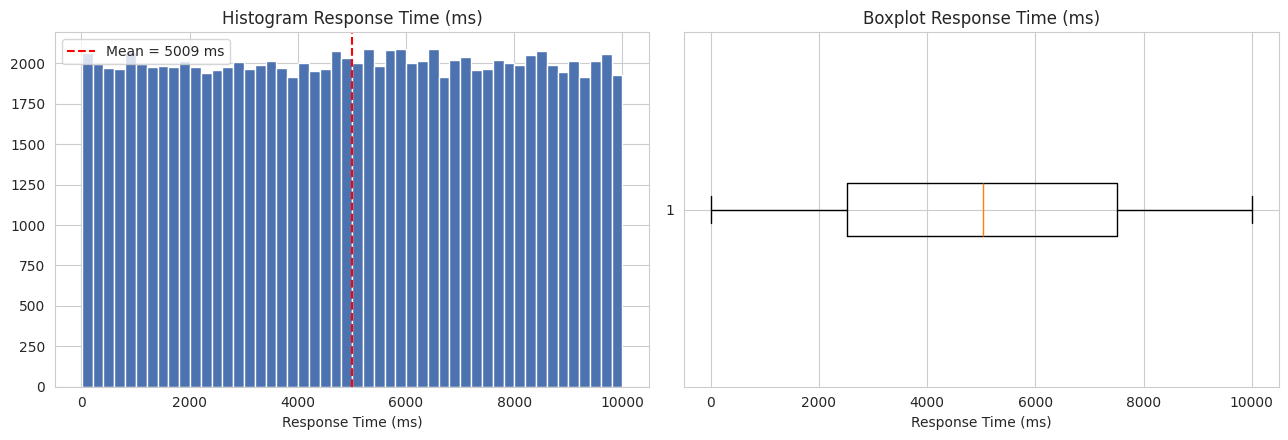

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].hist(df['Response_Time_ms'], bins=50, color='#4C72B0', edgecolor='white')
ax[0].axvline(df['Response_Time_ms'].mean(), color='red', linestyle='--', label=f"Mean = {df['Response_Time_ms'].mean():.0f} ms")
ax[0].set_title('Histogram Response Time (ms)')
ax[0].set_xlabel('Response Time (ms)')
ax[0].legend()

ax[1].boxplot(df['Response_Time_ms'], vert=False)
ax[1].set_title('Boxplot Response Time (ms)')
ax[1].set_xlabel('Response Time (ms)')

plt.tight_layout()
plt.show()

## 4. Breakdown Berdasarkan Kategori

Apakah rata-rata waktu respons beda-beda tergantung tingkat keparahan (`Severity`) atau jenis anomali (`Anomaly_Type`)?

In [ ]:
severity_summary = df.groupby('Severity')['Response_Time_ms'].agg(['mean', 'std', 'median', 'count']).round(2)
severity_summary = severity_summary.sort_values('mean')
severity_summary

,mean,std,median,count
Severity,,,,
Low,5002.18,2900.00,5010.0,24913
Medium,5002.39,2882.58,5016.5,25018
High,5007.39,2877.31,5040.5,24922
Critical,5025.33,2863.29,5052.0,25147


In [ ]:
anomaly_summary = df.groupby('Anomaly_Type')['Response_Time_ms'].agg(['mean', 'std', 'median', 'count']).round(2)
anomaly_summary = anomaly_summary.sort_values('mean')
anomaly_summary

,mean,std,median,count
Anomaly_Type,,,,
Database,4974.10,2877.31,4969.5,16644
System,5001.02,2900.07,5027.0,16676
Application,5006.88,2886.97,4986.0,16600
Security,5007.94,2855.65,5057.0,16893
Storage,5021.04,2878.49,5030.0,16601
Network,5045.31,2886.20,5107.5,16586


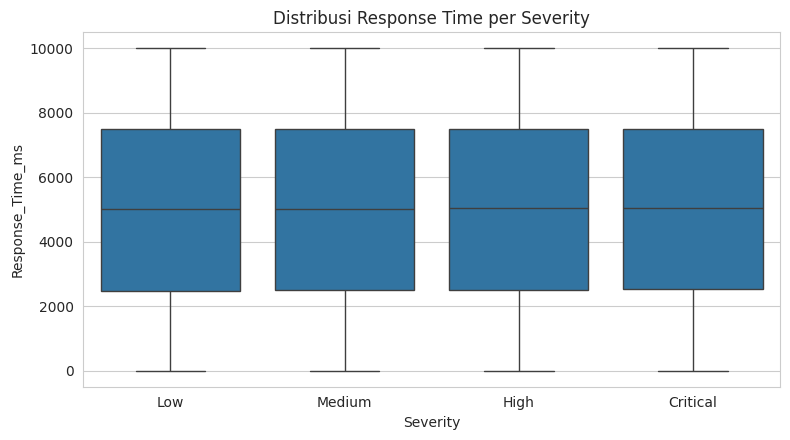

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='Severity', y='Response_Time_ms',
            order=['Low', 'Medium', 'High', 'Critical'], ax=ax)
ax.set_title('Distribusi Response Time per Severity')
plt.tight_layout()
plt.show()

## 5. Deteksi Outlier (Metode IQR)

In [ ]:
Q1 = df['Response_Time_ms'].quantile(0.25)
Q3 = df['Response_Time_ms'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Response_Time_ms'] < lower) | (df['Response_Time_ms'] > upper)]
print(f'Batas bawah: {lower:.1f} ms | Batas atas: {upper:.1f} ms')
print(f'Jumlah outlier: {len(outliers)} dari {len(df)} baris ({len(outliers)/len(df)*100:.2f}%)')

Batas bawah: -4963.5 ms | Batas atas: 14976.5 ms
Jumlah outlier: 0 dari 100000 baris (0.00%)


## 6. Ringkasan Tambahan (opsional)



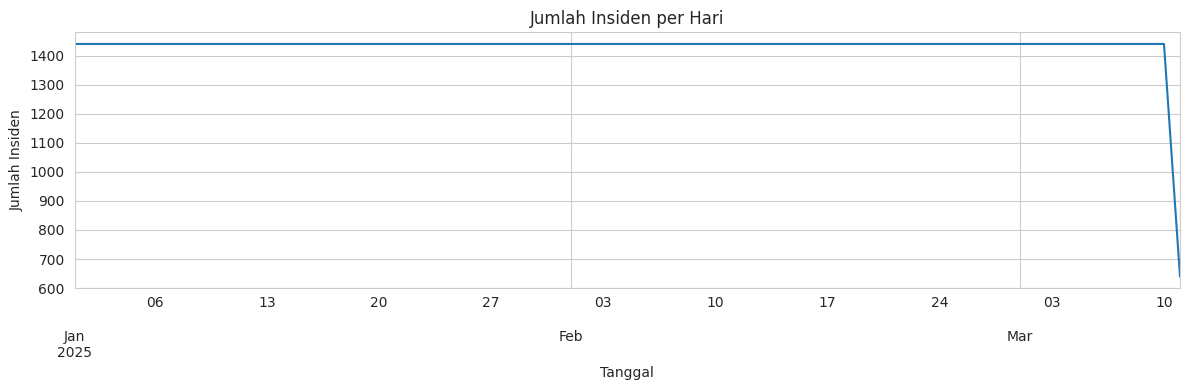

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
daily_counts = df.set_index('Timestamp').resample('D').size()

plt.figure(figsize=(12, 4))
daily_counts.plot()
plt.title('Jumlah Insiden per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Insiden')
plt.tight_layout()
plt.show()

# **KESIMPULAN**

Berdasarkan hasil eksplorasi data terhadap 100.000 baris data Logging & Monitoring Anomalies, variabel Response_Time_ms memiliki rata-rata 5009,35 ms (SD = 2880,76 ms) dengan distribusi yang relatif simetris (skewness ≈ 0) dan datar (kurtosis negatif), tanpa missing value, duplikat, maupun outlier. Tingkat keparahan (Severity) dan jenis anomali (Anomaly_Type) tidak menunjukkan pengaruh signifikan terhadap waktu respons, dengan selisih rata-rata antar kategori kurang dari 1,5%. Jumlah insiden harian relatif stabil sepanjang periode pengamatan.

# **Cell A — Simulasi Sampling Distribution**

In [ ]:
from scipy import stats

np.random.seed(42)
population = df['Response_Time_ms'].values
population_mean = population.mean()
population_std = population.std()

n = 50
num_samples = 1000

sample_means = np.array([
    np.random.choice(population, size=n, replace=False).mean()
    for _ in range(num_samples)
])

print(f'Rata-rata populasi: {population_mean:.2f} ms')
print(f'Rata-rata dari {num_samples} sample means: {sample_means.mean():.2f} ms')
print(f'Std sampling distribution (empiris): {sample_means.std():.2f} ms')
print(f'Standard Error teoritis: {population_std/np.sqrt(n):.2f} ms')

Rata-rata populasi: 5009.35 ms
Rata-rata dari 1000 sample means: 5006.00 ms
Std sampling distribution (empiris): 406.73 ms
Standard Error teoritis: 407.40 ms


# **Cell B — Plot histogram-nya**

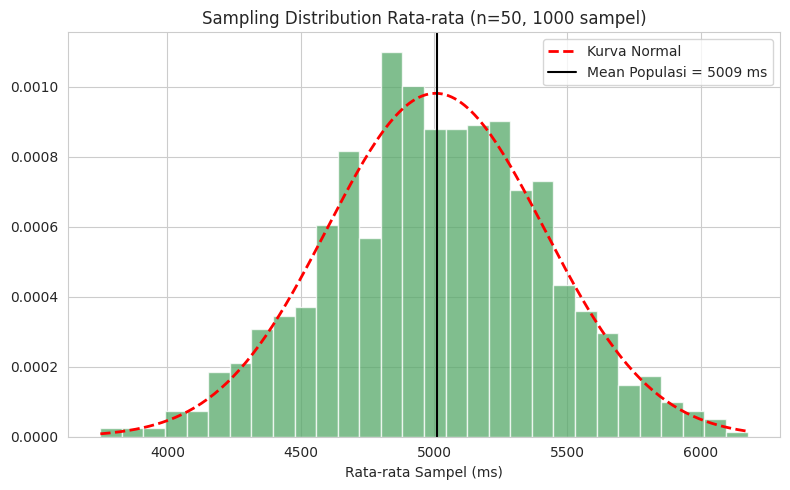

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(sample_means, bins=30, density=True, color='#55A868', edgecolor='white', alpha=0.75)
x = np.linspace(sample_means.min(), sample_means.max(), 200)
plt.plot(x, stats.norm.pdf(x, sample_means.mean(), sample_means.std()), 'r--', linewidth=2, label='Kurva Normal')
plt.axvline(population_mean, color='black', label=f'Mean Populasi = {population_mean:.0f} ms')
plt.title(f'Sampling Distribution Rata-rata (n={n}, {num_samples} sampel)')
plt.xlabel('Rata-rata Sampel (ms)')
plt.legend()
plt.tight_layout()
plt.show()

# **Cell C — Hitung 95% Confidence Interval**

In [ ]:
np.random.seed(7)
n_sample = 100
sample = np.random.choice(population, size=n_sample, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)
se = sample_std / np.sqrt(n_sample)

confidence = 0.95
t_crit = stats.t.ppf((1 + confidence) / 2, df=n_sample - 1)
margin_error = t_crit * se

ci_lower = sample_mean - margin_error
ci_upper = sample_mean + margin_error

print(f'Sample mean             : {sample_mean:.2f} ms')
print(f'Sample std              : {sample_std:.2f} ms')
print(f'Standard Error          : {se:.2f} ms')
print(f't-critical (df={n_sample-1}, 95%) : {t_crit:.3f}')
print(f'Margin of Error         : {margin_error:.2f} ms')
print(f'95% Confidence Interval : [{ci_lower:.2f}, {ci_upper:.2f}] ms')
print()
print(f'Mean populasi sebenarnya: {population_mean:.2f} ms')
print('Apakah mean populasi masuk ke dalam CI?', ci_lower <= population_mean <= ci_upper)

Sample mean             : 5195.46 ms
Sample std              : 2776.91 ms
Standard Error          : 277.69 ms
t-critical (df=99, 95%) : 1.984
Margin of Error         : 551.00 ms
95% Confidence Interval : [4644.46, 5746.46] ms

Mean populasi sebenarnya: 5009.35 ms
Apakah mean populasi masuk ke dalam CI? True


# **Cell D — Visualisasi CI-nya:**

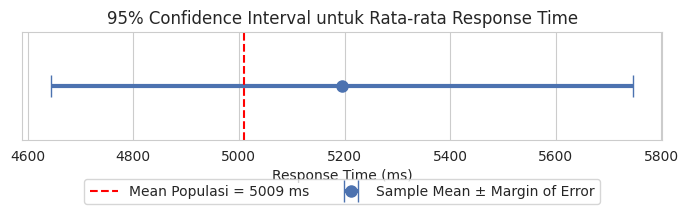

In [ ]:
plt.figure(figsize=(7, 2.5))
plt.errorbar(sample_mean, 1, xerr=margin_error, fmt='o', color='#4C72B0',
             ecolor='#4C72B0', elinewidth=3, capsize=8, markersize=8, label='Sample Mean ± Margin of Error')
plt.axvline(population_mean, color='red', linestyle='--', label=f'Mean Populasi = {population_mean:.0f} ms')
plt.yticks([])
plt.title('95% Confidence Interval untuk Rata-rata Response Time')
plt.xlabel('Response Time (ms)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.tight_layout()
plt.show()

# **Cell E — Bonus: cara alternatif hitung CI pakai Bootstrap**

In [ ]:
np.random.seed(0)
boot_means = np.array([
    np.random.choice(sample, size=len(sample), replace=True).mean()
    for _ in range(5000)
])

ci_lower_boot = np.percentile(boot_means, 2.5)
ci_upper_boot = np.percentile(boot_means, 97.5)

print(f'95% CI (Bootstrap)      : [{ci_lower_boot:.2f}, {ci_upper_boot:.2f}] ms')
print(f'95% CI (t-distribution) : [{ci_lower:.2f}, {ci_upper:.2f}] ms')

95% CI (Bootstrap)      : [4658.93, 5744.80] ms
95% CI (t-distribution) : [4644.46, 5746.46] ms
